# GMSM Vegetation Monitoring (WP3.2)

This notebook walks step by step through three experiment settings used in our vegetation monitoring benchmark, and shows how the **GMSM framework** handles each of them.

## What this demonstration covers

1. **Processing remote sensing time series (S2TS)**
   - Sentinel-2 multi-temporal imagery → DOFA encoder → Temporal Attention Network (TAN) → regression head
2. **Processing a single hyperspectral image (EnMAP)**
   - EnMAP single-scene imagery → DOFA encoder → regression head
3. **Processing multi-modal inputs (S2TS + EnMAP)**
   - S2TS features + EnMAP features → cross-modality fusion → regression head

To keep the demo focused and easy to follow, we report results for **one target**: `merged_SR` (Species Richness).

## Demo-friendly protocol

| Setting | Folds | Epochs | Batch | Model |
|---|---|---|---|---|
| S2TS only             | 5 | 50  | 16 | DOFA (frozen) → TAN → scalar |
| EnMAP only            | 5 | 50  | 16 | DOFA (frozen) → MLP → scalar |
| S2TS + EnMAP (Fusion) | 5 | 50 | 16 | DOFA (frozen) → TAN-proj + Cross-Modality Fusion → scalar |

All three use the same 5-fold split (`random_state=42`). Metrics are reported as **mean ± std across the five folds**.

## Section 0 — Environment setup

In [1]:
import os
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import tifffile as tif
import rasterio
from rasterio.warp import transform as rio_transform
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="Can't initialize NVML")

_cwd = Path.cwd().resolve()
_project_root = None
for cand in [_cwd] + list(_cwd.parents):
    if (cand / "core").exists() and (cand / "tasks").exists():
        _project_root = cand
        break
if _project_root is None:
    fallback = (_cwd / "../../..").resolve()
    if (fallback / "core").exists():
        _project_root = fallback
if _project_root is not None and str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from core.models.dofa.models_dwv import vit_base_patch16

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Can't initialize NVML")
    try:
        _has_cuda = torch.cuda.is_available()
    except Exception:
        _has_cuda = False
device = torch.device("cuda" if _has_cuda else "cpu")
print(f"Device: {device}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (9, 6)

N_SPLITS     = 5
EPOCHS       = 50
EPOCHS_MULTI = 100
BATCH_SIZE   = 16
LR           = 1e-3
WEIGHT_DECAY = 1e-4
SPLIT_SEED   = 42
TRAIN_SEED   = 1234


def set_seed(seed: int = TRAIN_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(TRAIN_SEED)

BASE_DIR = Path(".").resolve()
if not (BASE_DIR / "enmap_wavelengths.json").exists():
    candidate = Path("tasks/WP3.2_vegetation/experiments").resolve()
    if (candidate / "enmap_wavelengths.json").exists():
        BASE_DIR = candidate

REFERENCE_CSV = (BASE_DIR.parent / "data" / "reference" / "vm_reference_32.csv").resolve()
S2TS_DIR      = (BASE_DIR.parent / "data" / "eodata" / "processed" / "Sentinel-2" / "S2_L2A").resolve()
ENMAP_TIF     = (BASE_DIR.parent / "data" / "eodata" / "processed" / "EnMAP" / "ENMAP_20240814.TIF").resolve()
ENMAP_WL_JSON = (BASE_DIR / "enmap_wavelengths.json").resolve()
DOFA_CKPT     = (BASE_DIR.parents[2] / "core" / "models" / "dofa" / "checkpoint" / "DOFA_ViT_base_e100.pth").resolve()

print("REFERENCE_CSV:", REFERENCE_CSV, "exists:", REFERENCE_CSV.exists())
print("S2TS_DIR     :", S2TS_DIR,      "exists:", S2TS_DIR.exists())
print("ENMAP_TIF    :", ENMAP_TIF,     "exists:", ENMAP_TIF.exists())
print("DOFA_CKPT    :", DOFA_CKPT,     "exists:", DOFA_CKPT.exists())


Device: cuda
REFERENCE_CSV: /home/project/WP3.1_GMSM/tasks/WP3.2_vegetation/data/reference/vm_reference_32.csv exists: True
S2TS_DIR     : /home/project/WP3.1_GMSM/tasks/WP3.2_vegetation/data/eodata/processed/Sentinel-2/S2_L2A exists: True
ENMAP_TIF    : /home/project/WP3.1_GMSM/tasks/WP3.2_vegetation/data/eodata/processed/EnMAP/ENMAP_20240814.TIF exists: True
DOFA_CKPT    : /home/project/WP3.1_GMSM/core/models/dofa/checkpoint/DOFA_ViT_base_e100.pth exists: True


### Reproducibility

All sources of randomness in this notebook are fixed so that a fresh run from top to bottom on the same machine produces identical numbers:

- Python `random`, NumPy, PyTorch (CPU and CUDA) are seeded with `TRAIN_SEED = 1234` via `set_seed()`
- `torch.backends.cudnn.deterministic = True`, `benchmark = False`
- The 5-fold split uses a fixed `KFold(random_state=42, shuffle=True)`
- Every k-fold runner re-calls `set_seed(TRAIN_SEED)` at the start of its loop
- The DOFA checkpoint is loaded from a fixed file; feature extraction runs in `eval()` mode under `torch.no_grad()`

Small numerical drift may still appear across different hardware (GPU / CPU types, etc).

## Section 1 — Load labels and select target

Our in-situ vegetation dataset covers 32 plots with three target variables. The final comparison in this demo focus on `merged_SR` (Species richness).

In [2]:
data_df = pd.read_csv(REFERENCE_CSV)
display(data_df[["x_lon", "y_lat", "merged_SR", "merged_LAI", "FVC"]].head())

TARGET_NAME    = "merged_SR"
TARGET_DISPLAY = "Species Richness"
ALL_TARGETS    = ["merged_SR", "merged_LAI", "FVC"]

lons     = data_df["x_lon"].values
lats     = data_df["y_lat"].values
y_target = data_df[TARGET_NAME].values.astype(np.float32)            # [N]      - single-modal use
y_all    = data_df[ALL_TARGETS].values.astype(np.float32)            # [N, 3]   - multi-modal use

print(f"\nPrimary target: {TARGET_NAME} ({TARGET_DISPLAY})")
print(f"  mean    = {y_target.mean():.3f}")
print(f"  std     = {y_target.std():.3f}")
print(f"  min/max = {y_target.min():.3f} / {y_target.max():.3f}")


,x_lon,y_lat,merged_SR,merged_LAI,FVC
0,12.557672,47.425472,9,1.38,0.16200
1,12.563467,47.428802,12,3.65,0.46417
2,12.563660,47.429696,16,0.91,0.50403
3,12.557238,47.422966,17,0.46,0.52720
4,12.558531,47.422476,14,2.34,0.60439



Primary target: merged_SR (Species Richness)
  mean    = 14.419
  std     = 3.260
  min/max = 7.000 / 19.000


## Section 2 — Pixel extraction from rasters

Extract raw pixel values from satellite image data using latitude and longitude.

1. Open the raster **once**, read **all bands together** via `src.read()` → a `(bands, H, W)` NumPy cube that stays in memory.
2. Convert each plot's `(lon, lat)` to raster (row, col) using `src.index(...)` in the raster's native CRS.
3. Index the cached cube directly in memory.

In [129]:
def read_raster_cube(path):
    with rasterio.open(str(path)) as src:
        cube = src.read().astype(np.float32)
        meta = {
            "crs": src.crs,
            "bounds": src.bounds,
            "index": src.index,
            "count": src.count,
        }
    return cube, meta


def lonlat_to_rowcol(lon, lat, meta):
    xs, ys = rio_transform("EPSG:4326", meta["crs"], [lon], [lat])
    x, y = xs[0], ys[0]
    b = meta["bounds"]
    if not (b.left <= x <= b.right and b.bottom <= y <= b.top):
        raise ValueError(f"({x}, {y}) out of image bounds")
    return meta["index"](x, y)


def sample_cube(cube, meta, lons, lats):
    out = np.empty((len(lons), cube.shape[0]), dtype=np.float32)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        r, c = lonlat_to_rowcol(lon, lat, meta)
        out[i] = np.nan_to_num(cube[:, r, c])
    return out


## Section 3 — Load the DOFA foundation model

**DOFA (Dynamic One-For-All)** is the multimodal EO foundation model. It takes a wavelength list and a raster input, and returns a 768-dim feature vector. In this notebook it is used as a **frozen encoder** for all three experiments.

In [130]:
check_point = torch.load(str(DOFA_CKPT), map_location=device, weights_only=False)
dofa = vit_base_patch16().to(device)
dofa.load_state_dict(check_point, strict=False)
dofa.eval()

with open(ENMAP_WL_JSON, "r", encoding="utf-8") as f:
    enmap_wavelengths = json.load(f)
s2_wavelengths = [0.49, 0.56, 0.665, 0.705, 0.74, 0.783, 0.842, 0.865, 1.61, 2.19]

print("DOFA ViT-B/16 loaded and set to eval mode.")

DOFA ViT-B/16 loaded and set to eval mode.


## Section 4 — Experiment A: S2TS only

### 4.1 Extract S2TS features via DOFA

In [131]:
def extract_s2ts_spectra(s2ts_dir, lons, lats):
    tif_files = sorted(p for p in Path(s2ts_dir).glob("*.tif"))
    print(f"Found {len(tif_files)} Sentinel-2 time steps.")
    per_time = []
    for p in tif_files:
        cube, meta = read_raster_cube(p)
        spectra = sample_cube(cube, meta, lons, lats)
        per_time.append(spectra)
    return np.stack(per_time, axis=1)

print("Reading S2TS rasters ...")
t0 = time.time()
s2ts_spectra = extract_s2ts_spectra(S2TS_DIR, lons, lats)
num_samples, time_steps, num_bands = s2ts_spectra.shape
print(f"Raster read done in {time.time()-t0:.1f}s, shape = {s2ts_spectra.shape}")

feat_t = torch.tensor(s2ts_spectra, dtype=torch.float32).to(device)
feat_t = feat_t.view(-1, num_bands, 1, 1)
feat_t = F.interpolate(feat_t, size=(224, 224), mode="nearest")

print(f"Running DOFA on {feat_t.shape[0]} patches ...")
t0 = time.time()
with torch.no_grad():
    S2TS_RAW = dofa.forward_features(feat_t, wave_list=s2_wavelengths)
S2TS_PER_TIME = S2TS_RAW.view(num_samples, time_steps, 768)
S2TS_FEATURES = S2TS_PER_TIME.reshape(num_samples, time_steps * 768)
S2TS_TIME_STEPS = time_steps
print(f"DOFA forward done in {time.time()-t0:.1f}s.  S2TS_FEATURES: {tuple(S2TS_FEATURES.shape)}")


Reading S2TS rasters ...
Found 5 Sentinel-2 time steps.
Raster read done in 0.1s, shape = (31, 5, 10)
Running DOFA on 155 patches ...
DOFA forward done in 0.0s.  S2TS_FEATURES: (31, 3840)


### 4.2 Temporal Attention Network (TAN)

In [132]:
class TAN(nn.Module):
    def __init__(self, input_dim=768, num_heads=4, hidden_dim=128,
                 num_time_steps=5, output_dim=1, num_layers=1):
        super().__init__()
        self.num_time_steps = num_time_steps
        self.input_dim = input_dim
        self.num_layers = num_layers

        self.attention_layers = nn.ModuleList([
            nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads) for _ in range(num_layers)
        ])
        self.ffn_layers = nn.ModuleList([
            nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, input_dim))
            for _ in range(num_layers)
        ])
        self.fc = nn.Linear(input_dim, output_dim)

        position = torch.arange(0, num_time_steps, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, input_dim, 2).float() * (-math.log(10000.0) / input_dim))
        pe = torch.zeros(num_time_steps, input_dim)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pos_embedding = nn.Parameter(pe.unsqueeze(0), requires_grad=False)

    def forward(self, x):
        batch_size, total = x.shape
        x = x.view(batch_size, self.num_time_steps, total // self.num_time_steps).transpose(0, 1)
        x = x + self.pos_embedding.transpose(0, 1)
        for i in range(self.num_layers):
            attn, _ = self.attention_layers[i](x, x, x)
            x = self.ffn_layers[i](attn)
        x = x.mean(dim=0)
        return self.fc(x)


### 4.3 Shared training / evaluation utilities

In [133]:
def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true), np.asarray(y_pred))))

def corr2_score(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)


class VectorDataset(Dataset):
    def __init__(self, X, y):
        self.X = X; self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i].clone().detach().float(), torch.tensor(self.y[i], dtype=torch.float32)


def train_one(model, loader, epochs):
    opt  = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    crit = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            out = model(xb.to(device)).squeeze()
            loss = crit(out, yb.to(device))
            loss.backward(); opt.step()


def kfold_run(build_model, X, y, label, epochs=EPOCHS):
    set_seed(TRAIN_SEED)
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
    split_key = X.cpu() if torch.is_tensor(X) else X
    g = torch.Generator(); g.manual_seed(TRAIN_SEED)

    fold_r2, fold_rmse = [], []
    all_true, all_pred = [], []
    t0 = time.time()

    for fold, (tr, te) in enumerate(kf.split(split_key)):
        tr_ds = VectorDataset(X[tr], y[tr])
        te_ds = VectorDataset(X[te], y[te])
        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
        te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = build_model().to(device)
        train_one(model, tr_loader, epochs=epochs)

        model.eval()
        f_true, f_pred = [], []
        with torch.no_grad():
            for xb, yb in te_loader:
                out = model(xb.to(device)).squeeze()
                f_true.extend(np.atleast_1d(yb.cpu().numpy()).flatten().tolist())
                f_pred.extend(np.atleast_1d(out.cpu().numpy()).flatten().tolist())

        r2_f   = corr2_score(f_true, f_pred)
        rmse_f = rmse_score(f_true, f_pred)
        fold_r2.append(r2_f); fold_rmse.append(rmse_f)
        all_true.extend(f_true); all_pred.extend(f_pred)
        print(f"[{label}] Fold {fold+1}/{N_SPLITS}  R²={r2_f:.3f}  RMSE={rmse_f:.3f}  (elapsed {time.time()-t0:.1f}s)")

    r2_m, r2_s = float(np.mean(fold_r2)),   float(np.std(fold_r2))
    rmse_m, rmse_s = float(np.mean(fold_rmse)), float(np.std(fold_rmse))
    print(f"[{label}] MEAN ± STD   R² = {r2_m:.3f} ± {r2_s:.3f}   RMSE = {rmse_m:.3f} ± {rmse_s:.3f}")

    return {
        "fold_r2": np.array(fold_r2), "fold_rmse": np.array(fold_rmse),
        "r2_mean": r2_m, "r2_std": r2_s, "rmse_mean": rmse_m, "rmse_std": rmse_s,
        "y_true":  np.array(all_true), "y_pred":  np.array(all_pred),
    }


### 4.4 Run 5-fold CV for `merged_SR` (S2TS)

In [134]:
def build_tan():
    return TAN(input_dim=768, num_time_steps=S2TS_TIME_STEPS, output_dim=1, num_layers=1)

s2ts_res = kfold_run(build_tan, S2TS_FEATURES, y_target, label="S2TS", epochs=EPOCHS)


[S2TS] Fold 1/5  R²=0.164  RMSE=3.417  (elapsed 0.4s)
[S2TS] Fold 2/5  R²=0.103  RMSE=4.443  (elapsed 0.9s)
[S2TS] Fold 3/5  R²=0.552  RMSE=2.149  (elapsed 1.5s)
[S2TS] Fold 4/5  R²=0.074  RMSE=2.805  (elapsed 2.0s)
[S2TS] Fold 5/5  R²=0.226  RMSE=5.632  (elapsed 2.5s)
[S2TS] MEAN ± STD   R² = 0.224 ± 0.172   RMSE = 3.689 ± 1.231


## Section 5 — Experiment B: EnMAP only

### 5.1 Extract EnMAP features

In [135]:
print("Reading EnMAP GeoTIFF once into memory ...")
t0 = time.time()
ENMAP_CUBE, ENMAP_META = read_raster_cube(ENMAP_TIF)
print(f"  cube shape = {ENMAP_CUBE.shape}, read in {time.time()-t0:.1f}s")

G_MEANS = np.nan_to_num(ENMAP_CUBE).mean(axis=(1, 2), keepdims=True)
G_STDS  = np.nan_to_num(ENMAP_CUBE).std(axis=(1, 2),  keepdims=True)

spectra = sample_cube(ENMAP_CUBE, ENMAP_META, lons, lats)
spectra = (spectra - G_MEANS[:, 0, 0]) / (G_STDS[:, 0, 0] + 1e-8)
print(f"  per-plot spectra shape = {spectra.shape}")

del ENMAP_CUBE

feats = torch.tensor(spectra[:, :, None, None], dtype=torch.float32).to(device)
feats = F.interpolate(feats, size=(224, 224), mode="nearest")

print(f"Running DOFA on {feats.shape[0]} EnMAP patches ...")
t0 = time.time()
with torch.no_grad():
    ENMAP_FEATURES = dofa.forward_features(feats, wave_list=enmap_wavelengths)
print(f"DOFA forward done in {time.time()-t0:.1f}s. EnMAP feature shape: {tuple(ENMAP_FEATURES.shape)}")


Reading EnMAP GeoTIFF once into memory ...
  cube shape = (224, 1232, 1257), read in 5.0s
  per-plot spectra shape = (31, 224)
Running DOFA on 31 EnMAP patches ...
DOFA forward done in 0.0s. EnMAP feature shape: (31, 768)


### 5.2 Run 5-fold CV for `merged_SR` (EnMAP)

In [136]:
class MLP(nn.Module):
    def __init__(self, input_dim=768, hidden=128, output_dim=1, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, output_dim),
        )
    def forward(self, x):
        return self.net(x)

def build_mlp():
    return MLP(input_dim=ENMAP_FEATURES.shape[1], hidden=128, output_dim=1)

enmap_res = kfold_run(build_mlp, ENMAP_FEATURES, y_target, label="EnMAP", epochs=EPOCHS)


[EnMAP] Fold 1/5  R²=0.561  RMSE=3.736  (elapsed 0.3s)
[EnMAP] Fold 2/5  R²=0.439  RMSE=3.788  (elapsed 0.6s)
[EnMAP] Fold 3/5  R²=0.004  RMSE=3.129  (elapsed 0.9s)
[EnMAP] Fold 4/5  R²=0.011  RMSE=2.908  (elapsed 1.2s)
[EnMAP] Fold 5/5  R²=0.081  RMSE=3.823  (elapsed 1.5s)
[EnMAP] MEAN ± STD   R² = 0.219 ± 0.234   RMSE = 3.477 ± 0.382


## Section 6 — Experiment C: S2TS + EnMAP (multi-modal)

- A **TAN projection** reduces the S2TS tensor `[N, T*768]` to `[N, 768]` by modelling the termporal dependency.
- A **Cross-Modality Fusion** module with bidirectional cross-attention combines the two 768-dim vectors from S2TS and EnMAP.

### 6.1 Project S2TS features with TAN

In [137]:
set_seed(TRAIN_SEED)

tan_proj = TAN(input_dim=768, num_heads=4, hidden_dim=128,
               num_time_steps=S2TS_TIME_STEPS, output_dim=768, num_layers=2).to(device)
tan_proj.eval()
with torch.no_grad():
    S2TS_PROJ = tan_proj(S2TS_FEATURES)              # [N, 768]

print("S2TS_PROJ:", tuple(S2TS_PROJ.shape))
print("ENMAP_FEATURES:", tuple(ENMAP_FEATURES.shape))


S2TS_PROJ: (31, 768)
ENMAP_FEATURES: (31, 768)


### 6.2 Cross-Modality Fusion model

In [138]:
class CrossModalityFusion(nn.Module):
    def __init__(self, feature_dim=768, fusion_dim=512):
        super().__init__()
        self.s2ts_to_enmap = nn.MultiheadAttention(embed_dim=feature_dim, num_heads=8)
        self.enmap_to_s2ts = nn.MultiheadAttention(embed_dim=feature_dim, num_heads=8)

        self.fusion_layer = nn.Sequential(
            nn.Linear(feature_dim * 2, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        self.output_layers = nn.ModuleDict({
            "merged_SR":  nn.Linear(fusion_dim, 1),
            "merged_LAI": nn.Linear(fusion_dim, 1),
            "FVC":        nn.Linear(fusion_dim, 1),
        })

    def forward(self, s2ts_features, enmap_features):
        s = s2ts_features.unsqueeze(0)     # [1, B, 768]
        e = enmap_features.unsqueeze(0)
        s_att, _ = self.s2ts_to_enmap(s, e, e)
        e_att, _ = self.enmap_to_s2ts(e, s, s)
        fused = torch.cat([s_att.squeeze(0), e_att.squeeze(0)], dim=1)
        fused = self.fusion_layer(fused)
        return {k: layer(fused) for k, layer in self.output_layers.items()}


### 6.3 Run 5-fold CV for merged_SR (S2TS + EnMAP)

In [139]:
class MultiModalDataset(Dataset):
    def __init__(self, s2ts, enmap, y_multi):
        self.s2ts = s2ts; self.enmap = enmap; self.y_multi = y_multi
    def __len__(self):
        return len(self.s2ts)
    def __getitem__(self, i):
        return {
            "s2ts":  self.s2ts[i].clone().detach().float(),
            "enmap": self.enmap[i].clone().detach().float(),
            "y":     torch.tensor(self.y_multi[i], dtype=torch.float32),   # [3]
        }


def multi_kfold_run(S2TS_PROJ, ENMAP_FEATURES, y_all, target_idx=0, epochs=EPOCHS_MULTI):
    """5-fold CV with joint multi-target loss. Reports metrics for y_all[:, target_idx]."""
    set_seed(TRAIN_SEED)
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
    g  = torch.Generator(); g.manual_seed(TRAIN_SEED)

    fold_r2, fold_rmse = [], []
    all_true, all_pred = [], []
    t0 = time.time()

    split_key = S2TS_PROJ.cpu() if torch.is_tensor(S2TS_PROJ) else S2TS_PROJ

    for fold, (tr, te) in enumerate(kf.split(split_key)):
        tr_ds = MultiModalDataset(S2TS_PROJ[tr], ENMAP_FEATURES[tr], y_all[tr])
        te_ds = MultiModalDataset(S2TS_PROJ[te], ENMAP_FEATURES[te], y_all[te])
        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
        te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = CrossModalityFusion(feature_dim=768, fusion_dim=512).to(device)
        opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        crit  = nn.MSELoss()

        # Joint multi-target training
        model.train()
        for _ in range(epochs):
            for batch in tr_loader:
                s2ts  = batch["s2ts"].to(device)
                enmap = batch["enmap"].to(device)
                y     = batch["y"].to(device)              # [B, 3]
                opt.zero_grad()
                outs = model(s2ts, enmap)
                loss = 0
                for k, name in enumerate(ALL_TARGETS):
                    loss = loss + crit(outs[name].squeeze(), y[:, k])
                loss.backward(); opt.step()

        # Evaluate — single target only
        model.eval()
        f_true, f_pred = [], []
        with torch.no_grad():
            for batch in te_loader:
                s2ts  = batch["s2ts"].to(device)
                enmap = batch["enmap"].to(device)
                y     = batch["y"].to(device)
                outs  = model(s2ts, enmap)
                pred  = outs[ALL_TARGETS[target_idx]].squeeze()
                f_true.extend(np.atleast_1d(y[:, target_idx].cpu().numpy()).flatten().tolist())
                f_pred.extend(np.atleast_1d(pred.cpu().numpy()).flatten().tolist())

        r2_f   = corr2_score(f_true, f_pred)
        rmse_f = rmse_score(f_true, f_pred)
        fold_r2.append(r2_f); fold_rmse.append(rmse_f)
        all_true.extend(f_true); all_pred.extend(f_pred)
        print(f"[S2TS+EnMAP] Fold {fold+1}/{N_SPLITS}  R²={r2_f:.3f}  RMSE={rmse_f:.3f}  (elapsed {time.time()-t0:.1f}s)")

    r2_m, r2_s = float(np.mean(fold_r2)),   float(np.std(fold_r2))
    rmse_m, rmse_s = float(np.mean(fold_rmse)), float(np.std(fold_rmse))
    print(f"[S2TS+EnMAP] MEAN ± STD   R² = {r2_m:.3f} ± {r2_s:.3f}   RMSE = {rmse_m:.3f} ± {rmse_s:.3f}")

    return {
        "fold_r2": np.array(fold_r2), "fold_rmse": np.array(fold_rmse),
        "r2_mean": r2_m, "r2_std": r2_s, "rmse_mean": rmse_m, "rmse_std": rmse_s,
        "y_true":  np.array(all_true), "y_pred":  np.array(all_pred),
    }


multi_res = multi_kfold_run(S2TS_PROJ, ENMAP_FEATURES, y_all, target_idx=0, epochs=EPOCHS_MULTI)


[S2TS+EnMAP] Fold 1/5  R²=0.580  RMSE=3.634  (elapsed 1.3s)
[S2TS+EnMAP] Fold 2/5  R²=0.506  RMSE=3.412  (elapsed 2.7s)
[S2TS+EnMAP] Fold 3/5  R²=0.008  RMSE=3.080  (elapsed 4.2s)
[S2TS+EnMAP] Fold 4/5  R²=0.014  RMSE=3.092  (elapsed 5.5s)
[S2TS+EnMAP] Fold 5/5  R²=0.072  RMSE=3.660  (elapsed 6.9s)
[S2TS+EnMAP] MEAN ± STD   R² = 0.236 ± 0.253   RMSE = 3.376 ± 0.252


## Section 7 — Comparison of the three settings

All metrics below are reported as **mean ± std across the 5 folds**.

In [140]:
def fmt(mean, std):
    return f"{mean:.3f} ± {std:.3f}"

summary = pd.DataFrame([
    {"Input": "S2TS",
     "R²":   fmt(s2ts_res["r2_mean"],   s2ts_res["r2_std"]),
     "RMSE": fmt(s2ts_res["rmse_mean"], s2ts_res["rmse_std"])},
    {"Input": "EnMAP",
     "R²":   fmt(enmap_res["r2_mean"],   enmap_res["r2_std"]),
     "RMSE": fmt(enmap_res["rmse_mean"], enmap_res["rmse_std"])},
    {"Input": "S2TS & EnMAP",
     "R²":   fmt(multi_res["r2_mean"],   multi_res["r2_std"]),
     "RMSE": fmt(multi_res["rmse_mean"], multi_res["rmse_std"])},
])
print("Summary (merged_SR / Species Richness, 5-fold CV, mean ± std):")
display(summary)


Summary (merged_SR / Species Richness, 5-fold CV, mean ± std):


,Input,R²,RMSE
0,S2TS,0.224 ± 0.172,3.689 ± 1.231
1,EnMAP,0.219 ± 0.234,3.477 ± 0.382
2,S2TS & EnMAP,0.236 ± 0.253,3.376 ± 0.252


### 7.1 Bar chart — R² and RMSE with fold-wise error bars

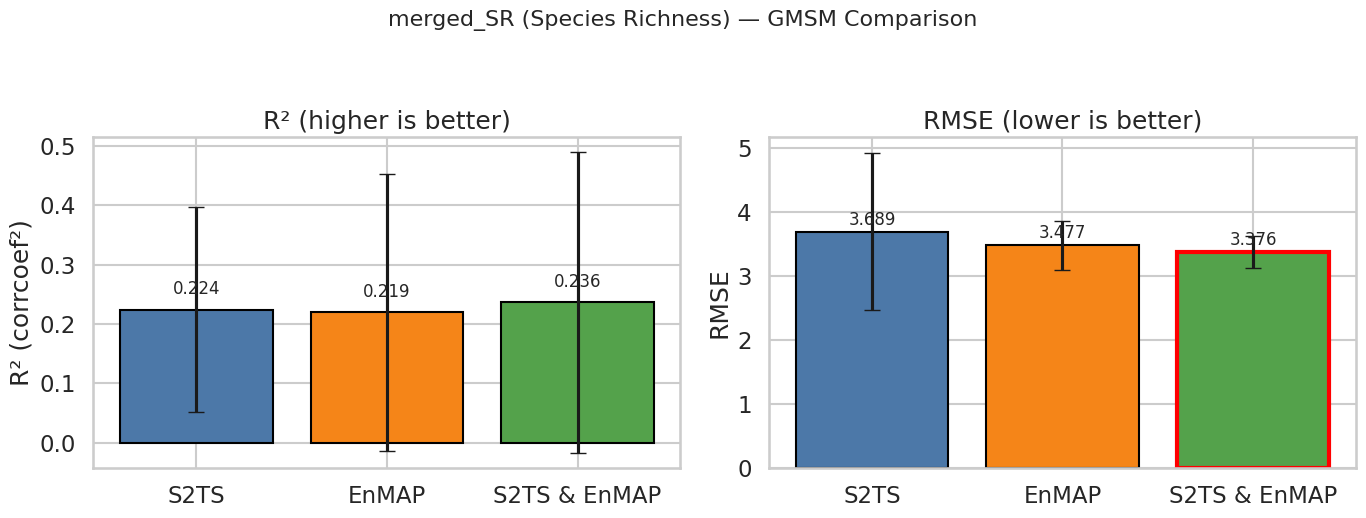

In [141]:
palette  = ["#4C78A8", "#F58518", "#54A24B"]
inputs   = ["S2TS", "EnMAP", "S2TS & EnMAP"]
r2_m     = [s2ts_res["r2_mean"],   enmap_res["r2_mean"],   multi_res["r2_mean"]]
r2_s     = [s2ts_res["r2_std"],    enmap_res["r2_std"],    multi_res["r2_std"]]
rmse_m   = [s2ts_res["rmse_mean"], enmap_res["rmse_mean"], multi_res["rmse_mean"]]
rmse_s   = [s2ts_res["rmse_std"],  enmap_res["rmse_std"],  multi_res["rmse_std"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(inputs, r2_m, yerr=r2_s, color=palette, edgecolor="black", capsize=6)
axes[0].set_title("R² (higher is better)"); axes[0].set_ylabel("R² (corrcoef²)")
for i, v in enumerate(r2_m):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=12)

axes[1].bar(inputs, rmse_m, yerr=rmse_s, color=palette, edgecolor="black", capsize=6)
axes[1].set_title("RMSE (lower is better)"); axes[1].set_ylabel("RMSE")
for i, v in enumerate(rmse_m):
    axes[1].text(i, v + 0.05, f"{v:.3f}", ha="center", va="bottom", fontsize=12)

best_idx = int(np.argmin(rmse_m))
axes[1].patches[best_idx].set_edgecolor("red"); axes[1].patches[best_idx].set_linewidth(3)

plt.suptitle("merged_SR (Species Richness) — GMSM Comparison", y=1.05, fontsize=16)
plt.tight_layout(); plt.show()


## Summary

- GMSM can handle heterogeneous data modalities (SITS, single image, multi-modal inputs)
- Under a 5-fold CV protocol on `merged_SR`, the multi-modal configuration produces the best R2 and RMSE among the three settings reported above.

Full benchmark numbers (leave-one-out CV, deeper heads, longer training) are produced by the corresponding training scripts under `github.com/EU-horizon-multiminer/WP3.1_GMSM/tasks/WP3.2_vegetation/experiments/`, and will be released publicly upon publication of the manuscript.